# Netflix Titles Analysis

## Problem Statement
This analysis explores trends in Netflix titles over time and compares Movies and TV Shows
to understand how the platform’s content has evolved.

In [ ]:
import sys
!{sys.executable} -m pip install matplotlib


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
#CELL B
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/netflix")  # note: notebook is in notebooks/
CSV_PATH = DATA_DIR / "netflix_titles.csv"


In [3]:
#CELL C
if not CSV_PATH.exists():
    raise FileNotFoundError(
        f"Missing {CSV_PATH}. Make sure netflix_titles.csv is in data/netflix/."
    )

df = pd.read_csv(CSV_PATH)
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Data Dictionary (key columns)
- **type**: Whether the title is a Movie or TV Show.
- **title**: Title name.
- **country**: Country/countries associated with the title (may contain multiple, comma-separated).
- **date_added**: Date the title was added to Netflix.
- **release_year**: Year the title was originally released.
- **rating**: Content rating (e.g., TV-MA, PG-13).
- **duration**: Duration in minutes (Movies) or number of seasons (TV Shows).
- **listed_in**: Categories/genres (comma-separated).


In [4]:
#CELL E
def add_year_added(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Parse date_added into datetime and create a year_added column.
    Returns a copy (does not mutate the original dataframe).
    """
    df2 = dataframe.copy()
    df2["date_added"] = pd.to_datetime(df2["date_added"], errors="coerce")
    df2["year_added"] = df2["date_added"].dt.year
    return df2

df = add_year_added(df)
df[["title", "type", "date_added", "year_added"]].head(10)


,title,type,date_added,year_added
0,Dick Johnson Is Dead,Movie,2021-09-25,2021.0
1,Blood & Water,TV Show,2021-09-24,2021.0
2,Ganglands,TV Show,2021-09-24,2021.0
3,Jailbirds New Orleans,TV Show,2021-09-24,2021.0
4,Kota Factory,TV Show,2021-09-24,2021.0
5,Midnight Mass,TV Show,2021-09-24,2021.0
6,My Little Pony: A New Generation,Movie,2021-09-24,2021.0
7,Sankofa,Movie,2021-09-24,2021.0
8,The Great British Baking Show,TV Show,2021-09-24,2021.0
9,The Starling,Movie,2021-09-24,2021.0


In [5]:
#CELL F
df.shape, df.columns.tolist()


((8807, 13),
 ['show_id',
  'type',
  'title',
  'director',
  'cast',
  'country',
  'date_added',
  'release_year',
  'rating',
  'duration',
  'listed_in',
  'description',
  'year_added'])

## Analysis 1: How has the number of titles added to Netflix changed over time?


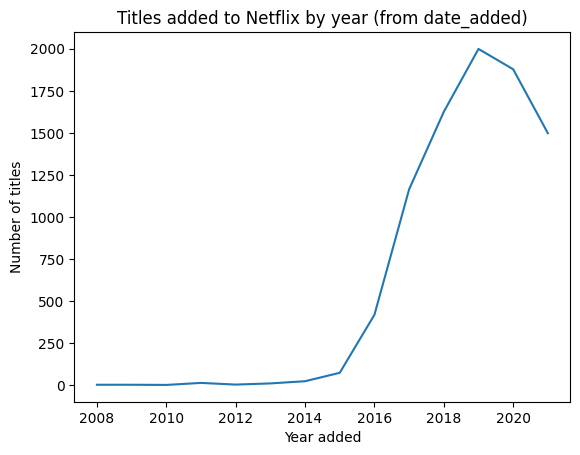

In [6]:
#CELL H
added_per_year = (
    df.dropna(subset=["year_added"])
      .groupby("year_added")
      .size()
      .sort_index()
)

plt.figure()
plt.plot(added_per_year.index, added_per_year.values)
plt.xlabel("Year added")
plt.ylabel("Number of titles")
plt.title("Titles added to Netflix by year (from date_added)")
plt.show()


**Interpretation:** This line chart shows how many titles were added to Netflix each year based on the `date_added` column. The trend highlights years where Netflix added more content and years where additions slowed down. Any dips or missing early years may also be influenced by missing `date_added` values in the dataset.


## Analysis 2: Do Movies and TV Shows differ in ratings distribution?


In [7]:
#CELL K
rating_by_type = (
    df.groupby(["type", "rating"])
      .size()
      .reset_index(name="count")
)

rating_by_type.head()


,type,rating,count
0,Movie,66 min,1
1,Movie,74 min,1
2,Movie,84 min,1
3,Movie,G,41
4,Movie,NC-17,3


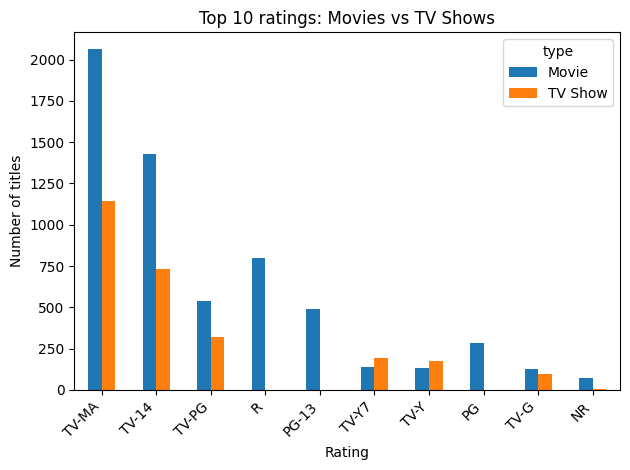

In [8]:
#CELL L
pivot = rating_by_type.pivot(index="rating", columns="type", values="count").fillna(0)

# Keep top 10 ratings overall for readability
top_ratings = df["rating"].value_counts().head(10).index
pivot_top = pivot.loc[top_ratings]

pivot_top.plot(kind="bar")
plt.xlabel("Rating")
plt.ylabel("Number of titles")
plt.title("Top 10 ratings: Movies vs TV Shows")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretation:** This grouped bar chart compares how common each rating is for Movies versus TV Shows. Some ratings appear more frequently for one type than the other, which suggests differences in the target audiences and content style between Movies and TV Shows. Limiting to the top 10 ratings keeps the comparison readable while still showing the most common categories.
